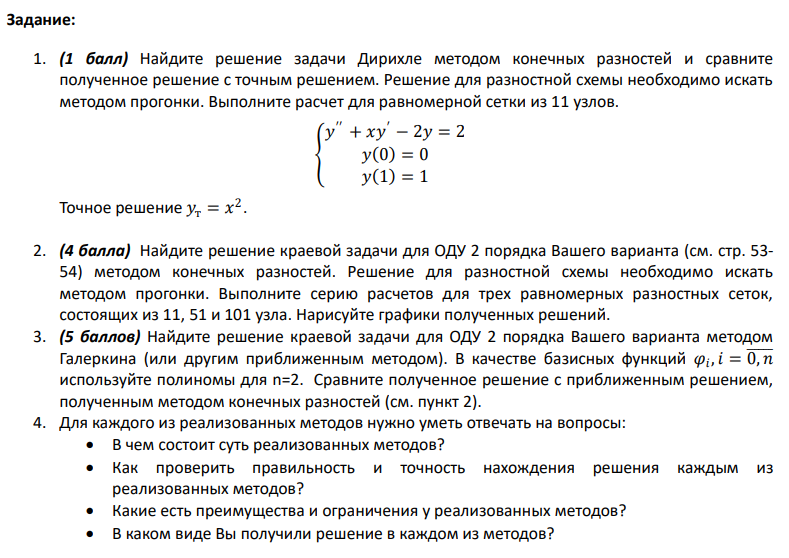  
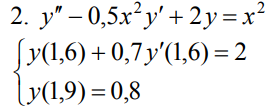

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad


def p(x):
    return -0.5 * x ** 2


def q(x):
    return 2


def f(x):
    return x**2


a = 1.6
b = 1.9
alpha = 0.7 
mu1 = 2
mu2 = 0.8



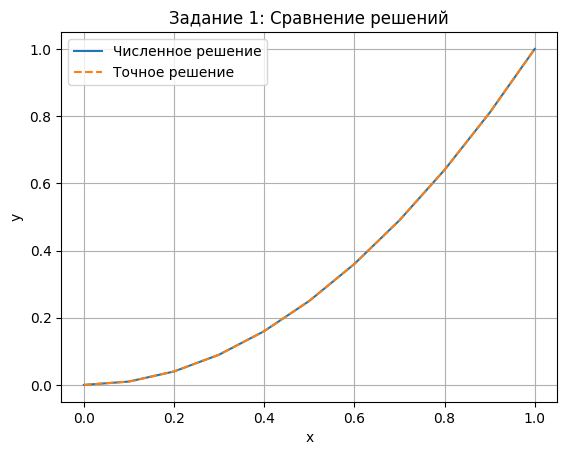

Задание 1: Решение задачи Дирихле
Численное решение:
 [4.5817794e-16 1.0000000e-02 4.0000000e-02 9.0000000e-02 1.6000000e-01
 2.5000000e-01 3.6000000e-01 4.9000000e-01 6.4000000e-01 8.1000000e-01
 1.0000000e+00]
Точное решение:    [0.   0.01 0.04 0.09 0.16 0.25 0.36 0.49 0.64 0.81 1.  ]
Максимальная ошибка: 4.581779400325558e-16
Средняя ошибка:     1.8200743942290128e-16


In [10]:
def p(x): return -0.5 * x**2
def q(x): return 2.0
def f(x): return x**2

a, b = 1.6, 1.9
alpha, mu1, mu2 = 0.7, 2.0, 0.8

def solve_dirichlet():
    n = 11
    h = 1 / (n - 1)
    x = np.linspace(0, 1, n)

    A = np.zeros((n, n))
    b_vec = np.full(n, 2.0)

    # Схема центральных разностей для y'':
    for i in range(1, n - 1):
        A[i, i - 1] = 1 / h**2
        A[i, i]     = -2 / h**2
        A[i, i + 1] = 1 / h**2

    # Граничные условия Дирихле
    A[0, 0] = 1;        b_vec[0] = 0
    A[n-1, n-1] = 1;    b_vec[n-1] = 1

    y = np.linalg.solve(A, b_vec)
    y_exact = x**2

    plt.figure()
    plt.plot(x, y, label='Численное решение')
    plt.plot(x, y_exact, label='Точное решение', linestyle='--')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Задание 1: Сравнение решений')
    plt.grid()
    plt.show()

    error = np.abs(y - y_exact)
    print("Задание 1: Решение задачи Дирихле")
    print("Численное решение:\n", y)
    print("Точное решение:   ", y_exact)
    print("Максимальная ошибка:", np.max(error))
    print("Средняя ошибка:    ", np.mean(error))

solve_dirichlet()

при n=11
y = [-0.90612477 -0.78157657 -0.64808849 -0.50524282 -0.35258738 -0.18963194
 -0.01584434  0.16935391  0.36659258  0.57655815  0.8       ]
при n=51
y = [-1.01736488 -0.99150175 -0.96527285 -0.93867499 -0.91170494 -0.88435943
 -0.85663512 -0.82852864 -0.80003655 -0.77115534 -0.74188149 -0.71221138
 -0.68214135 -0.65166768 -0.6207866  -0.58949425 -0.55778674 -0.5256601
 -0.4931103  -0.46013323 -0.42672473 -0.39288056 -0.35859642 -0.32386793
 -0.28869063 -0.25306001 -0.21697146 -0.18042029 -0.14340176 -0.10591102
 -0.06794315 -0.02949314  0.0094441   0.04887376  0.08880109  0.12923146
  0.17017033  0.21162324  0.25359585  0.29609389  0.33912322  0.38268978
  0.42679962  0.47145892  0.51667394  0.56245108  0.60879682  0.65571778
  0.70322071  0.75131245  0.8       ]
при n=101
y = [-1.03202542 -1.01903102 -1.0059449  -0.99276664 -0.97949587 -0.96613216
 -0.95267513 -0.93912436 -0.92547944 -0.91173996 -0.89790549 -0.88397563
 -0.86994995 -0.85582801 -0.8416094  -0.82729367 -0.812880

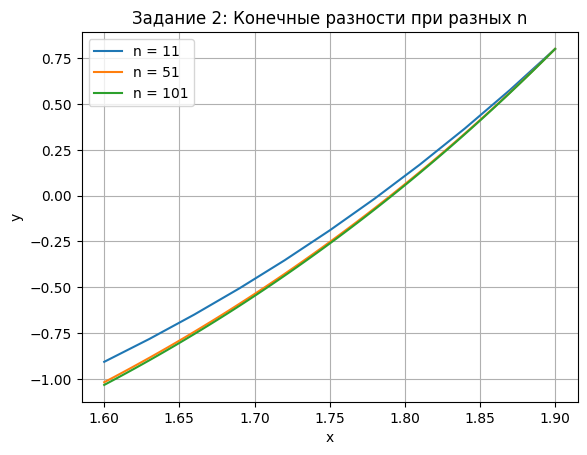


Максимальная разница между решениями при разных n (шаг 0.05):
     x        n=11        n=51       n=101      max_diff
--------------------------------------------------------
  1.60   -0.906125   -1.017365   -1.032025  1.2590e-01
  1.65   -0.692585   -0.790409   -0.803206  1.1062e-01
  1.70   -0.454358   -0.536369   -0.547072  9.2715e-02
  1.75   -0.189632   -0.253060   -0.261420  7.1788e-02
  1.80    0.107621    0.062183    0.056317  5.1304e-02
  1.85    0.436581    0.412096    0.409007  2.7574e-02
  1.90    0.800000    0.800000    0.800000  0.0000e+00


In [11]:

def finite_difference(n):
    x1, x2 = 1.6, 1.9
    h = (x2 - x1) / (n - 1)
    x = np.linspace(x1, x2, n)

    A = np.zeros((n, n))
    b_vec = np.zeros(n)

    # Схема центральных разностей:
    # A[i,i-1] = 1/h^2 - p(xi)/(2h)
    # A[i,i]   = -2/h^2 + q(xi)
    # A[i,i+1] = 1/h^2 + p(xi)/(2h)
    for i in range(1, n - 1):
        pi = p(x[i])
        A[i, i - 1] = 1/h**2 - pi / (2*h)
        A[i, i]     = -2/h**2 + q(x[i])
        A[i, i + 1] = 1/h**2 + pi / (2*h)
        b_vec[i] = f(x[i])

    # Левое ГУ (Robin): y(x1) + 0.7*y'(x1) = 2
    # Правая разность y' ~~ (y[1]-y[0])/h:
    # y[0]*(1 - 0.7/h) + y[1]*(0.7/h) = 2
    A[0, 0] = 1 - alpha / h
    A[0, 1] = alpha / h
    b_vec[0] = mu1

    # Правое ГУ (Дирихле): y(x2) = 0.8
    A[n-1, n-1] = 1
    b_vec[n-1] = mu2

    y = np.linalg.solve(A, b_vec)
    return x, y


n_values = [11, 51, 101]

plt.figure()
for n in n_values:
    x, y = finite_difference(n)
    print(f"при n={n}")
    print(f"y = {y}")
    plt.plot(x, y, label=f'n = {n}')
    

plt.xlabel('x')
plt.ylabel('y')
plt.title('Задание 2: Конечные разности при разных n')
plt.legend()
plt.grid()
plt.show()

# Максимальная разница между решениями при разных n (шаг 0.05)
print("\nМаксимальная разница между решениями при разных n (шаг 0.05):")
x_check = np.arange(1.6, 1.91, 0.05)
results_per_n = {}
for n in n_values:
    xn, yn = finite_difference(n)
    results_per_n[n] = np.interp(x_check, xn, yn)
header = f"{'x':>6}" + "".join(f"  {'n='+str(n):>10}" for n in n_values) + f"  {'max_diff':>12}"
print(header)
print("-" * len(header))
for i, xval in enumerate(x_check):
    vals = [results_per_n[n][i] for n in n_values]
    max_diff = max(vals) - min(vals)
    row = f"{xval:6.2f}" + "".join(f"  {results_per_n[n][i]:10.6f}" for n in n_values) + f"  {max_diff:.4e}"
    print(row)


Коэффициенты c: [ 10.065438 -18.797884   7.32702 ]
  y(1.6)+0.7·y'(1.6) = 2.00000000  (должно 2.0) → OK —  ГУ выполнено
  y(1.9)              = 0.80000000  (должно 0.8) → OK  — ГУ выполнено

Невязка max|L[y]−f|: 3.6818e+00

Коэффициенты c: [ -5.754495  17.811939 -31.429535  23.556083  -4.640097  -4.341245
   3.500438  -1.032723   0.118915]
  y(1.6)+0.7·y'(1.6) = 2.00000000  (должно 2.0) → OK —  ГУ выполнено
  y(1.9)              = 0.80000000  (должно 0.8) → OK  — ГУ выполнено

Невязка max|L[y]−f|: 1.0907e-05


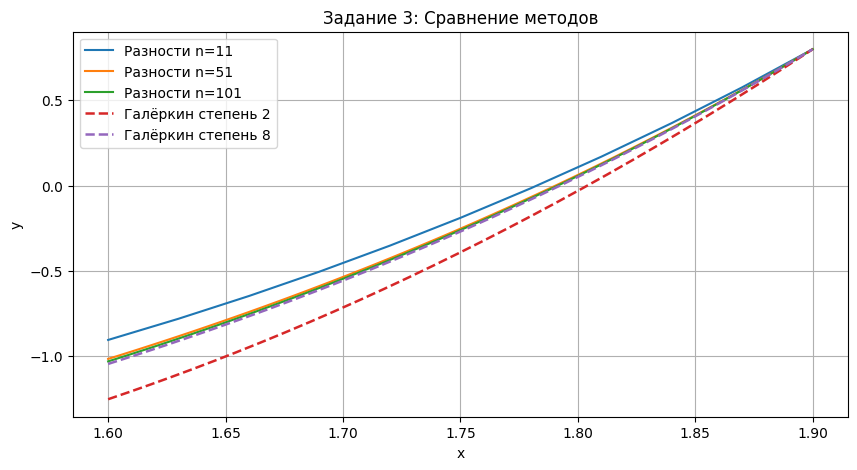

In [ ]:
def galerkin(degree=2):
    x1, x2 = 1.6, 1.9
    N = degree + 1
    phi   = [lambda x, k=k: x**k for k in range(N)]
    dphi  = [lambda x, k=k: k * x**(k-1) if k > 0 else 0.0 for k in range(N)]
    ddphi = [lambda x, k=k: k*(k-1)*x**(k-2) if k > 1 else 0.0 for k in range(N)]

    # Матрица и правая часть Галёркина
    # Aij = integral L[phij]·phii dx,  L[u] = u'' + p(x)u' + q(x)u
    A = np.zeros((N, N))
    b_vec = np.zeros(N)
    for i in range(N):
        for j in range(N):
            integrand = lambda x, i=i, j=j: (
                ddphi[j](x) + p(x) * dphi[j](x) + q(x) * phi[j](x)
            ) * phi[i](x)
            A[i, j] = quad(integrand, x1, x2)[0]
        rhs_fn = lambda x, i=i: f(x) * phi[i](x)
        b_vec[i] = quad(rhs_fn, x1, x2)[0]
        
    # Заменяем строки 0 и 1 на граничные условия
    A[0, :] = [phi[j](x2) for j in range(N)] # y(1.9) = 0.8
    b_vec[0] = mu2
    A[1, :] = [phi[j](x1) + alpha * dphi[j](x1) for j in range(N)] # y(1.6 )+0.7y'(1.6) = 2
    b_vec[1] = mu1
    coeffs = np.linalg.solve(A, b_vec)

    # Финальное решение и его производные
    def y_sol(x):   return sum(coeffs[k] * phi[k](x)   for k in range(N))
    def dy_sol(x):  return sum(coeffs[k] * dphi[k](x)  for k in range(N))
    def ddy_sol(x): return sum(coeffs[k] * ddphi[k](x) for k in range(N))
    # Подстановка в граничные условия
    left_val  = y_sol(x1) + alpha * dy_sol(x1)
    right_val = y_sol(x2)
    print(f"\nКоэффициенты c: {np.round(coeffs, 6)}")
    print(f"  y(1.6)+0.7·y'(1.6) = {left_val:.8f}  (должно {mu1}) → {'OK —  ГУ выполнено' if abs(left_val - mu1) < 1e-8 else 'НЕ ОК'}")
    print(f"  y(1.9)              = {right_val:.8f}  (должно {mu2}) → {'OK  — ГУ выполнено' if abs(right_val - mu2) < 1e-8 else 'НЕ ОК'}")
    # Невязка: r(x) = y''(x) + p(x)*y'(x) + q(x)*y(x) - f(x)
    # Если решение точное — невязка нулевая; иначе отражает погрешность ап проксимации
    x_res = np.linspace(x1, x2, 200)
    residuals = np.array([
        ddy_sol(xi) + p(xi)*dy_sol(xi) + q(xi)*y_sol(xi) - f(xi)
        for xi in x_res
    ])
    print(f"\nНевязка max|L[y]−f|: {np.max(np.abs(residuals)):.4e}")
    x_plot = np.linspace(x1, x2, 200)
    y_plot = np.array([y_sol(xi) for xi in x_plot])
    return x_plot, y_plot

plt.figure(figsize=(10, 5))
for n in [11, 51, 101]:
    x, y = finite_difference(n)
    plt.plot(x, y, label=f'Разности n={n}')
for deg in [2, 8]:
    xg, yg = galerkin(degree=deg)
    plt.plot(xg, yg, '--', linewidth=1.8, label=f'Галёркин степень {deg}')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Задание 3: Сравнение методов')
plt.legend()
plt.grid()
plt.show()

У Галёркина получается большое отклонение в следствие ограничения n=2.
Чтобы получить точное значение нужно либо использовать модифицированную версию Галёркина, либо увеличить n

phi(0-2) проверить на граничные условия(соответ образом) - ОБЯЗ
фин реш подставить в гран условие с коэф с1 и с2, если удовлетв то всё ОК, значит базис плох, можно попробовать увел n 